In [5]:
import librosa
import numpy as np

SAMPLE_RATE = 8000
N_MELS = 128

def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    # Log-Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, fmax=1000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Spectral Contrast
    contrast = librosa.feature.spectral_contrast(
        y=y, sr=sr, fmin=50, n_bands=6
    )

    # Flatten and concatenate
    features = np.concatenate([
        mel_db.flatten(),
        contrast.flatten()
    ])

    return features


In [6]:
import os

DATASET_PATH = "/home/feliciano/Documents/DATASET_SEABREAM_SEGMENTED/Segmented_1s"

X = []
y = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)
            label = os.path.basename(root)  # folder name = class label

            features = extract_features(file_path)
            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Loaded:", X.shape[0], "samples")


Loaded: 75000 samples


In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [8]:
import time
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

svm = SVC(kernel="rbf", probability=True)

# Training time
start_train = time.time()
svm.fit(X_train, y_train)
train_time = time.time() - start_train

# Inference time
start_inf = time.time()
y_pred = svm.predict(X_test)
inf_time = (time.time() - start_inf) / len(X_test)

# Probabilities for ROC-AUC
y_prob = svm.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

try:
    auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
except:
    auc = None

cm = confusion_matrix(y_test, y_pred)

print("\n--- SVM RESULTS (1-second segments) ---")
print("Training time:", round(train_time, 4), "s")
print("Inference time per sample:", round(inf_time * 1000, 4), "ms")
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", auc)
print("\nConfusion Matrix:\n", cm)



--- SVM RESULTS (1-second segments) ---
Training time: 2788.5169 s
Inference time per sample: 30.3012 ms
Accuracy: 0.9921
Precision: 0.9909
Recall: 0.9723
F1-score: 0.9771
ROC-AUC: 0.9999102443299035

Confusion Matrix:
 [[599   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   1   0   0   0   0   0   0]
 [  0 598   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   1   1   0   0   0   0   0]
 [  0   0 600   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 600   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 600   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 600   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 600


--- SVM RESULTS (1-second segments) ---
Training time: 2589.6168 s
Inference time per sample: 29.7632 ms
Accuracy: 0.9921
Precision: 0.9909
Recall: 0.9723
F1-score: 0.9771
ROC-AUC: 0.9999105464291246

Confusion Matrix (raw counts):
 [[599   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   1   0   0   0   0   0   0]
 [  0 598   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   1   1   0   0   0   0   0]
 [  0   0 600   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 600   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 600   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 600   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   

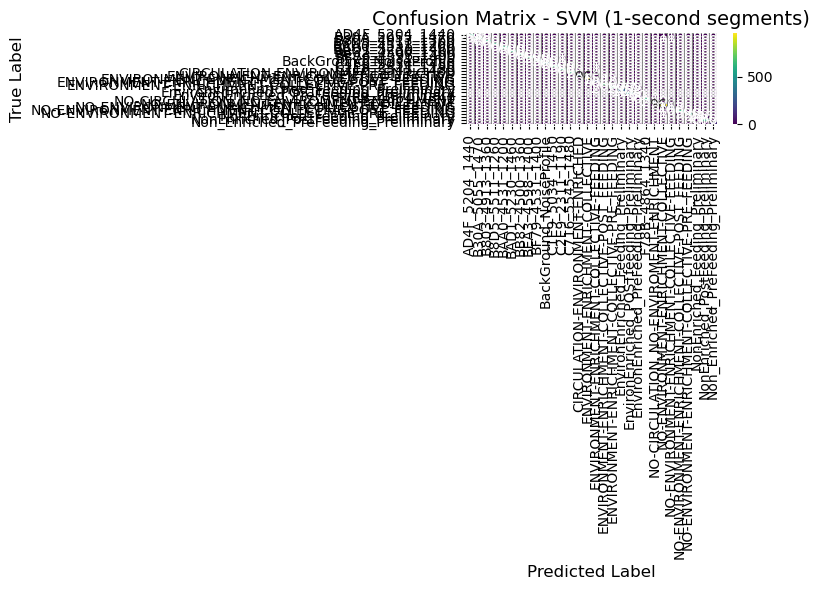

In [9]:
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# -----------------------------
# Train SVM
# -----------------------------
svm = SVC(kernel="rbf", probability=True)

start_train = time.time()
svm.fit(X_train, y_train)
train_time = time.time() - start_train

# -----------------------------
# Inference
# -----------------------------
start_inf = time.time()
y_pred = svm.predict(X_test)
inf_time = (time.time() - start_inf) / len(X_test)

y_prob = svm.predict_proba(X_test)

# -----------------------------
# Metrics
# -----------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

try:
    auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
except:
    auc = None

cm = confusion_matrix(y_test, y_pred)

print("\n--- SVM RESULTS (1-second segments) ---")
print("Training time:", round(train_time, 4), "s")
print("Inference time per sample:", round(inf_time * 1000, 4), "ms")
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", auc)
print("\nConfusion Matrix (raw counts):\n", cm)

# -----------------------------
# Beautiful Confusion Matrix
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

class_names = le.classes_  # label names from encoder

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",     # try: "magma", "crest", "rocket", "Blues"
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Confusion Matrix - SVM (1-second segments)", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()
